# Exploration Strategies: Epsilon-Greedy

## 📚 Learning Objectives

By completing this notebook, you will:
- Understand the exploration-exploitation dilemma
- Implement Epsilon-Greedy exploration strategy
- Visualize the impact of different epsilon values
- Compare exploration vs exploitation behavior on CartPole and FrozenLake in **optional** Parts 3c–3d (GIF + slider)
- Apply Epsilon-Greedy to RL problems

## 🔗 Where this fits

**Builds on:** Course 03 (AIAT 113) — Unit 5, lesson 04 "Applying Central Limit Theorem with Simulations" — you watched a sample mean settle down only as the sample size grew; an action tried twice has a mean you cannot trust yet, and ε-greedy is the rule that keeps buying it more samples.

## Recommended run order

**Core path (minimum story — run code cells top to bottom once):** Parts **1–2** → **Part 3** (static ε comparison) → **Part 4** (epsilon decay) → **bandit example** → **Summary**.

**Optional intuition (same mechanism, richer media — skip on a first pass if you are time-boxed):** **Part 3b** (live ε slider), **Parts 3c–3d** (CartPole + FrozenLake GIF/step scrubbers), and the late **auto-plots** cell.

**If a cell raises `RuntimeError` about `epsilon_greedy_action`:** rerun **Part 2**, then the cell that failed.

---

## Official Structure Reference

This notebook covers practical activities from **Course 09, Unit 1**:
- Exploration strategies: programming Epsilon-Greedy strategy and visualizing its impact

---

## Introduction

**Exploration-Exploitation Dilemma**: RL agents must balance exploring new actions (to discover better rewards) with exploiting known good actions (to maximize rewards). **Epsilon-Greedy** is a simple but effective exploration strategy.

If students see the word **Gym** in older material, interpret it here as **Gymnasium-style environment tooling** unless the notebook says otherwise.


## Lesson Brief

This lesson explains the exploration-exploitation dilemma through the simplest practical strategy: **epsilon-greedy**.

Students will see why an agent cannot only exploit what it already knows, and why some controlled exploration is necessary for learning.

Why this matters: this idea appears again in Q-learning, bandits, and deep RL.

If students understand this lesson well, many later design choices become easier to explain.

### If Python feels hard right now

- Run code cells **from top to bottom** the first time; later you can re-run one cell after you change it.
- In code cells, a line that starts with `# ` (hash + space) is a **hint for the very next line**—read the hint, then read the code under it.
- You do **not** need to memorize syntax. Follow the story: *what is stored*, *what gets printed*, and *what the plot is trying to show*.
- If something errors, read the last line of the red traceback first—it usually names the problem in plain language.


## 🌍 Real case: the Yahoo front page, 33 million clicks, and 12.5%

The Today Module was the big panel at the top of the old Yahoo! front page. An editorial pool of
articles competed for one slot, and the system had to keep choosing which article to show — while
never being told what *would* have happened had it shown a different one. That is exactly the
exploration problem this notebook is about, at production scale.

Li, Chu, Langford and Schapire published the study at WWW 2010 ("A Contextual-Bandit Approach to
Personalized News Article Recommendation"). They logged **over 33 million events** from the live
front page and used them to evaluate bandit algorithms offline. Their contextual method (LinUCB, the
algorithm you meet in Unit 4, lesson 03) delivered a **12.5% click lift over a standard
context-free bandit** — and the paper notes the advantage grows as data gets scarcer.

The reason that lift exists is the reason ε exists. A system that always serves the article with the
best current estimate never learns that a different article would have done better, because it never
shows it. Every click it collects confirms the choice it already made.

**What goes wrong without this.** You get a system that is confidently stuck. Watch for it in the
worked bandit example at the end of this notebook: with **ε = 0.0** the agent pulled arm 0 all 500
times and averaged **0.126** reward. With **ε = 0.1** it averaged **0.302**. The greedy agent was not
unlucky and it was not badly coded — it was correct about the only arm it had ever seen.


## Recommended YouTube Video

To reinforce this lesson, watch **Jacob Schrum - "Q-Learning: What do those parameters mean? Epsilon, Gamma, and Alpha explained"**:
[Watch on YouTube](https://www.youtube.com/watch?v=XrxgdpduWOU)

Why this pick:
- short focused format.
- Explains epsilon-greedy in plain language without overcomplicating the math.
- Strong support for the exploration versus exploitation idea in this notebook.

## Student Support Pack

Use this section as a checkpoint before and after the main code cells so the idea stays clearer than the syntax.

### Key Terms
- Exploration: trying uncertain actions.
- Exploitation: using the current best action.
- Epsilon: explore probability.
- Epsilon decay: lowering ε over episodes so the agent explores a lot early and becomes greedier later.
- Regret: loss from not always choosing the best action.

### Quick Check
- Why is pure exploitation risky early?
- What changes when epsilon is high or low?
- How do the plots reveal the trade-off?

### Common Mistakes
- Assuming exploration means permanent randomness.
- Using one lucky run as proof.
- Confusing exploration rate with learning rate.


## Self-check (same goals as the introduction)

Use the **Learning Objectives** at the top as the master list. Before leaving, you should be able to:

1. **Explain** why pure exploitation early can lock onto a suboptimal action.
2. **Trace** ε-greedy: with probability ε pick a random action, else pick the greedy action from current estimates.
3. **Connect** ε to the bar charts, the live slider, and the motion demos (steady vs jittery).
4. **Describe** epsilon decay in one sentence (what decreases over time, and why that helps training).

If any item feels shaky, rerun the **core path** in order, then revisit the optional Parts **3b–3d**.


### Step Guide

**What this cell does:** Installs plotting/math helpers (`%pip`) and imports what the epsilon-greedy demos need.

**How to read it (weak Python OK):** If the cell ends quietly, you are ready. If `%pip` complains, fix that before any plots.

**What to expect in the output:** Pip logs and a friendly “libraries imported” confirmation.

**Pip noise:** upgrade notices from pip are common; ignore them if the cell ends **without** a red traceback.

**If you feel lost:** This is setup only—no exploration math yet.


In [1]:
# Setup step: install the small packages needed for this lesson.
# Students can rerun this cell if the environment is missing a dependency.

# Line magic: Jupyter/IPython directive for this line only.
%pip install "gymnasium[classic-control]" numpy matplotlib ipywidgets pillow -q
# Load a library so you can use its ready-made functions and types below.
import numpy as np
# Load a library so you can use its ready-made functions and types below.
import matplotlib.pyplot as plt
# Load a library so you can use its ready-made functions and types below.
import gymnasium as gym  # successor to OpenAI Gym; API-compatible for imports

# Show text or numbers in the cell output area under the code.
print("✅ Libraries imported!")
# Show text or numbers in the cell output area under the code.
print("\nExploration Strategies: Epsilon-Greedy")
# Show text or numbers in the cell output area under the code.
print("=" * 60)



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


✅ Libraries imported!

Exploration Strategies: Epsilon-Greedy


## Part 1: Understanding Epsilon-Greedy Strategy


### Step Guide

**What this cell does:** **Part 1** — explains epsilon-greedy in words: with probability ε explore, else exploit the best-known action.

**How to read it (weak Python OK):** Translate ε to a habit: “I roll dice; sometimes I ignore my best idea on purpose.”

**What to expect in the output:** Printed rules of thumb about ε values and decay schedules.

**If you feel lost:** Write ε = 0.1 as “10% random, 90% greedy” in your notes—that one line unlocks the whole lesson.


In [2]:
# Worked example: this cell runs the main scenario of the lesson step by step.
# Compare each printed result with the theory in the markdown so the execution tells a story.

# Show text or numbers in the cell output area under the code.
print("=" * 60)
# Show text or numbers in the cell output area under the code.
print("Part 1: Understanding Epsilon-Greedy Strategy")
# Show text or numbers in the cell output area under the code.
print("=" * 60)

# Show text or numbers in the cell output area under the code.
print("\nEpsilon-Greedy Algorithm:")
# Show text or numbers in the cell output area under the code.
print("  1. With probability ε (epsilon): Explore (choose random action)")
# Show text or numbers in the cell output area under the code.
print("  2. With probability 1-ε: Exploit (choose best known action)")

# Show text or numbers in the cell output area under the code.
print("\nKey Parameters:")
# Show text or numbers in the cell output area under the code.
print("  - ε (epsilon): Exploration rate (0.0 to 1.0)")
# Show text or numbers in the cell output area under the code.
print("  - ε = 1.0: Pure exploration (always random)")
# Show text or numbers in the cell output area under the code.
print("  - ε = 0.0: Pure exploitation (always greedy)")
# Show text or numbers in the cell output area under the code.
print("  - ε = 0.1: 10% exploration, 90% exploitation (common choice)")

# Show text or numbers in the cell output area under the code.
print("\nEpsilon Decay:")
# Show text or numbers in the cell output area under the code.
print("  - Start with high ε (more exploration)")
# Show text or numbers in the cell output area under the code.
print("  - Gradually decrease ε (more exploitation as agent learns)")
# Show text or numbers in the cell output area under the code.
print("  - Common: ε = 1.0 → 0.01 over training")

# Show text or numbers in the cell output area under the code.
print("\n✅ Epsilon-Greedy strategy understood!")


Part 1: Understanding Epsilon-Greedy Strategy

Epsilon-Greedy Algorithm:
  1. With probability ε (epsilon): Explore (choose random action)
  2. With probability 1-ε: Exploit (choose best known action)

Key Parameters:
  - ε (epsilon): Exploration rate (0.0 to 1.0)
  - ε = 1.0: Pure exploration (always random)
  - ε = 0.0: Pure exploitation (always greedy)
  - ε = 0.1: 10% exploration, 90% exploitation (common choice)

Epsilon Decay:
  - Start with high ε (more exploration)
  - Gradually decrease ε (more exploitation as agent learns)
  - Common: ε = 1.0 → 0.01 over training

✅ Epsilon-Greedy strategy understood!


## Part 2: Implementing Epsilon-Greedy


### Step Guide

**What this cell does:** **Part 2** — implements `epsilon_greedy_action` and runs a short scripted demo so you can **count explore vs exploit** decisions.

**How to read it (weak Python OK):** Watch the printed table of counts—does randomness match the ε you typed?

**What to expect in the output:** Step-by-step actions labeled explore/exploit plus totals.

**If you feel lost:** Change only `epsilon` and rerun; your counts should shift in a predictable direction.


In [3]:
# Worked example: this cell runs the main scenario of the lesson step by step.
# Compare each printed result with the theory in the markdown so the execution tells a story.

# Show text or numbers in the cell output area under the code.
print("\n" + "=" * 60)
# Show text or numbers in the cell output area under the code.
print("Part 2: Implementing Epsilon-Greedy")
# Show text or numbers in the cell output area under the code.
print("=" * 60)


# Function `epsilon_greedy_action` (what it does): Return (action, mode) where mode is 'explore' or 'exploit'.
def epsilon_greedy_action(q_values, epsilon, n_actions):
    """Return (action, mode) where mode is 'explore' or 'exploit'."""
    # If the condition is True, run the indented block under this line.
    if np.random.random() < epsilon:
        # Send a value back to whoever called this function.
        return np.random.randint(n_actions), "explore"
    # Send a value back to whoever called this function.
    return int(np.argmax(q_values)), "exploit"


# Example: a tiny bandit-style decision problem
# Save a value in a name so the next lines can read it.
n_actions = 4
# Another assignment—same idea: store a value for the lines below.
q_values = np.array([0.1, 0.3, 0.5, 0.2])
# Another assignment—same idea: store a value for the lines below.
epsilon = 0.3

# Show text or numbers in the cell output area under the code.
print(f"\nExample estimated values: {q_values}")
# Show text or numbers in the cell output area under the code.
print(f"Epsilon: {epsilon}")
# Show text or numbers in the cell output area under the code.
print("\nRunning epsilon-greedy for 20 steps:")

# Save a value in a name so the next lines can read it.
action_counts = np.zeros(n_actions)
# Another assignment—same idea: store a value for the lines below.
mode_counts = {"explore": 0, "exploit": 0}
# Start a loop: repeat the indented block once per item in the sequence.
for i in range(20):
    # Save a value in a name so the next lines can read it.
    action, mode = epsilon_greedy_action(q_values, epsilon, n_actions)
    # Another assignment—same idea: store a value for the lines below.
    action_counts[action] += 1
    # Another assignment—same idea: store a value for the lines below.
    mode_counts[mode] += 1
    # Show text or numbers in the cell output area under the code.
    print(f"  Step {i + 1}: Action {action} ({mode})")

# Show text or numbers in the cell output area under the code.
print("\nAction selection counts:")
# Start a loop: repeat the indented block once per item in the sequence.
for i in range(n_actions):
    # Show text or numbers in the cell output area under the code.
    print(f"  Action {i}: {int(action_counts[i])} times ({action_counts[i] / 20 * 100:.1f}%)")

# Save a value in a name so the next lines can read it.
best_action = int(np.argmax(q_values))
# Show text or numbers in the cell output area under the code.
print(f"\nBest current action: {best_action}")
# Show text or numbers in the cell output area under the code.
print(f"Explore decisions: {mode_counts['explore']}")
# Show text or numbers in the cell output area under the code.
print(f"Exploit decisions: {mode_counts['exploit']}")
# Show text or numbers in the cell output area under the code.
print("\nCheckpoint: even when one action looks best, epsilon-greedy still tries")
# Show text or numbers in the cell output area under the code.
print("other actions sometimes so the agent can discover better choices later.")



Part 2: Implementing Epsilon-Greedy

Example estimated values: [0.1 0.3 0.5 0.2]
Epsilon: 0.3

Running epsilon-greedy for 20 steps:
  Step 1: Action 2 (exploit)
  Step 2: Action 0 (explore)
  Step 3: Action 2 (exploit)
  Step 4: Action 2 (exploit)
  Step 5: Action 2 (exploit)
  Step 6: Action 2 (exploit)
  Step 7: Action 2 (explore)
  Step 8: Action 0 (explore)
  Step 9: Action 2 (exploit)
  Step 10: Action 2 (exploit)
  Step 11: Action 2 (exploit)
  Step 12: Action 2 (exploit)
  Step 13: Action 2 (exploit)
  Step 14: Action 2 (explore)
  Step 15: Action 2 (exploit)
  Step 16: Action 2 (exploit)
  Step 17: Action 0 (explore)
  Step 18: Action 2 (exploit)
  Step 19: Action 2 (exploit)
  Step 20: Action 2 (exploit)

Action selection counts:
  Action 0: 3 times (15.0%)
  Action 1: 0 times (0.0%)
  Action 2: 17 times (85.0%)
  Action 3: 0 times (0.0%)

Best current action: 2
Explore decisions: 5
Exploit decisions: 15

Checkpoint: even when one action looks best, epsilon-greedy still tries

## Part 3: Visualizing Impact of Different Epsilon Values


### Step Guide

**What this cell does:** **Part 3** — plots how different ε values change how often each action is picked (same Q-values, different randomness).

**How to read it (weak Python OK):** Read the legend and axis titles before interpreting bar heights.

**What to expect in the output:** A matplotlib figure comparing exploration percentages.

**If you feel lost:** If the plot fails, rerun Part 2 first so `q_values` and counters exist.



Part 3: Visualizing Impact of Different Epsilon Values

Action selection percentages for different epsilon values:
Action | ε=0.0 | ε=0.1 | ε=0.3 | ε=0.5 | ε=1.0
--------------------------------------------------
  0 | 0.0% | 2.1% | 6.6% | 13.7% | 26.4%
  1 | 0.0% | 2.2% | 8.8% | 12.9% | 25.1%
  2 | 100.0% | 93.7% | 76.9% | 61.4% | 24.1% <- best estimate
  3 | 0.0% | 2.0% | 7.7% | 12.0% | 24.4%


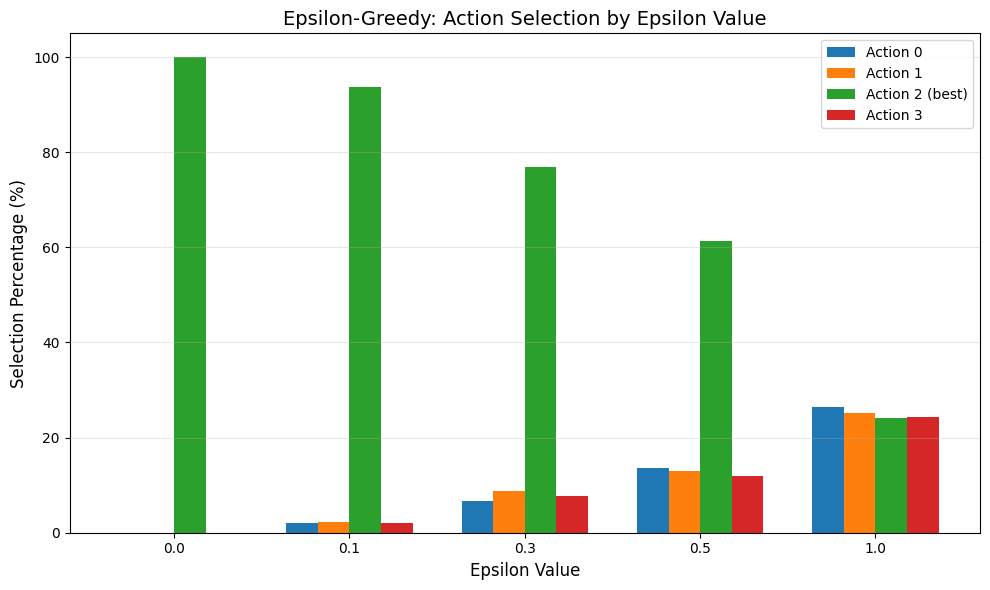


✅ Impact visualization complete!


In [4]:
# Worked example: this cell runs the main scenario of the lesson step by step.
# Compare each printed result with the theory in the markdown so the execution tells a story.

# Show text or numbers in the cell output area under the code.
print("\n" + "=" * 60)
# Show text or numbers in the cell output area under the code.
print("Part 3: Visualizing Impact of Different Epsilon Values")
# Show text or numbers in the cell output area under the code.
print("=" * 60)

# Test different epsilon values
# Save a value in a name so the next lines can read it.
epsilon_values = [0.0, 0.1, 0.3, 0.5, 1.0]
# Another assignment—same idea: store a value for the lines below.
n_steps = 1000
# Another assignment—same idea: store a value for the lines below.
n_actions = 4
# Another assignment—same idea: store a value for the lines below.
q_values = np.array([0.1, 0.3, 0.5, 0.2])
# Another assignment—same idea: store a value for the lines below.
best_action = int(np.argmax(q_values))

# Another assignment—same idea: store a value for the lines below.
results = {}

# Start a loop: repeat the indented block once per item in the sequence.
for epsilon in epsilon_values:
    # Save a value in a name so the next lines can read it.
    action_counts = np.zeros(n_actions)
    # Start a loop: repeat the indented block once per item in the sequence.
    for _ in range(n_steps):
        # Save a value in a name so the next lines can read it.
        action, _ = epsilon_greedy_action(q_values, epsilon, n_actions)
        # Another assignment—same idea: store a value for the lines below.
        action_counts[action] += 1
    # Another assignment—same idea: store a value for the lines below.
    results[epsilon] = action_counts / n_steps

# Show text or numbers in the cell output area under the code.
print("\nAction selection percentages for different epsilon values:")
# Show text or numbers in the cell output area under the code.
print("Action | ε=0.0 | ε=0.1 | ε=0.3 | ε=0.5 | ε=1.0")
# Show text or numbers in the cell output area under the code.
print("-" * 50)
# Start a loop: repeat the indented block once per item in the sequence.
for i in range(n_actions):
    # Save a value in a name so the next lines can read it.
    percentages = [f"{results[eps][i] * 100:.1f}%" for eps in epsilon_values]
    # Another assignment—same idea: store a value for the lines below.
    marker = " <- best estimate" if i == best_action else ""
    # Show text or numbers in the cell output area under the code.
    print(f"  {i} | {' | '.join(percentages)}{marker}")

# Visualize
# Unpack Matplotlib figure and axes array created by subplots().
fig, ax = plt.subplots(figsize=(10, 6))
# Save a value in a name so the next lines can read it.
x = np.arange(len(epsilon_values))
# Another assignment—same idea: store a value for the lines below.
width = 0.18

# Start a loop: repeat the indented block once per item in the sequence.
for i in range(n_actions):
    # Save a value in a name so the next lines can read it.
    percentages = [results[eps][i] * 100 for eps in epsilon_values]
    # Choose what text to draw in this cell for goals/pits vs numeric values/arrows.
    label = f"Action {i}" + (" (best)" if i == best_action else "")
    # Work on one plot panel: title, tick marks, axis labels, or drawings on that panel.
    ax.bar(x + i * width, percentages, width, label=label)

# Same plot panel as the line above—one more small plotting tweak.
ax.set_xlabel('Epsilon Value', fontsize=12)
# Same plot panel as the line above—one more small plotting tweak.
ax.set_ylabel('Selection Percentage (%)', fontsize=12)
# Same plot panel as the line above—one more small plotting tweak.
ax.set_title('Epsilon-Greedy: Action Selection by Epsilon Value', fontsize=14)
# Same plot panel as the line above—one more small plotting tweak.
ax.set_xticks(x + width * 1.5)
# Same plot panel as the line above—one more small plotting tweak.
ax.set_xticklabels([str(eps) for eps in epsilon_values])
# Same plot panel as the line above—one more small plotting tweak.
ax.legend()
# Same plot panel as the line above—one more small plotting tweak.
ax.grid(True, alpha=0.3, axis='y')
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.tight_layout()
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.show()

# Show text or numbers in the cell output area under the code.
print("\n✅ Impact visualization complete!")


## Part 3b (optional): Live ε sweep (interactive)

**Optional intuition:** Part 3 already shows the static bar-chart story. Use this if you want the same counts to update instantly when you drag **ε** (same `epsilon_greedy_action` helper as Part 2).

**Prerequisite:** run **Part 2** first.


In [5]:
# Interactive ε: re-sample action counts whenever the slider moves.

if "epsilon_greedy_action" not in globals():
    raise RuntimeError("Run Part 2 above first so `epsilon_greedy_action` exists, then rerun this cell.")

import ipywidgets as widgets
from IPython.display import clear_output, display

# Same toy Q-vector as Part 3 (best action is index 2 with value 0.5).
n_actions = 4
q_demo = np.array([0.1, 0.3, 0.5, 0.2])
best_action = int(np.argmax(q_demo))
n_steps_mc = 1200

# A dedicated output area lets us clear and redraw the chart in place on every slider move.
out = widgets.Output()


# Estimate how often each action would be picked at this ε by simulating many ε-greedy draws.
def mc_distribution(epsilon: float):
    counts = np.zeros(n_actions)
    for _ in range(n_steps_mc):
        a, _ = epsilon_greedy_action(q_demo, float(epsilon), n_actions)
        counts[a] += 1
    return counts / n_steps_mc


# Redraw the bar chart: green = best action by Q-value, grey = the rest; bar heights are pick percentages.
def draw(epsilon: float) -> None:
    import matplotlib.pyplot as plt

    with out:
        clear_output(wait=True)
        p = mc_distribution(epsilon)
        fig, ax = plt.subplots(figsize=(8.2, 4.4))
        colors = ["#16a34a" if i == best_action else "#94a3b8" for i in range(n_actions)]
        ax.bar(np.arange(n_actions), p * 100.0, color=colors)
        ax.set_ylim(0, 100)
        ax.set_xlabel("Action index")
        ax.set_ylabel("Approximate pick %")
        ax.set_title(f"ε-greedy — ε={epsilon:.2f}  (best Q is action {best_action})")
        for i, v in enumerate(p):
            ax.text(i, min(96.0, v * 100.0 + 2.0), f"{v * 100:.1f}%", ha="center", fontsize=10)
        plt.show()


# The ε slider: drag from 0 (always exploit) to 1 (always explore) and watch the bars shift.
eps_slider = widgets.FloatSlider(
    value=0.2, min=0.0, max=1.0, step=0.02, description="ε", readout_format=".2f"
)


# Whenever the slider moves, re-run the simulation and redraw the chart.
def on_eps(change):
    draw(float(change["new"]))


eps_slider.observe(on_eps, names="value")
display(widgets.VBox([eps_slider, out]))
draw(float(eps_slider.value))

## Part 3c (optional): Watch exploration on CartPole (GIF + step slider)

### Lesson Brief (why this is here)

Charts in Part 3 count *how often* each action is chosen. This part shows *what exploration looks like in motion* on a real Gymnasium environment.

We reuse the same `epsilon_greedy_action` helper from Part 2. The Q-vector here is a **tiny bias** toward pushing right (action `1`) at every step — not a full CartPole solution, just a fixed “habit” so exploitation is meaningful while exploration still injects random left/right tries.

**What to notice:** with **low ε**, motion looks steadier (mostly following the habit). With **high ε**, motion looks jittery (many random tries).

**Prerequisite:** run Part 2 first so `epsilon_greedy_action` exists.

### Step Guide

**What this cell does:** **Part 3c** — records CartPole frames under two ε settings and shows a GIF plus a step slider for each.

**How to read it (weak Python OK):** Watch motion first, numbers second. Jerky vs steady is the main signal.

**What to expect in the output:** Two short GIFs and two sliders (widgets). First run can take a few seconds.

**If you feel lost:** Re-run Part 2, then rerun this cell. If widgets do not appear, confirm `ipywidgets` is installed and Jupyter supports widgets.


Low ε=0.08  | frames=10 | return=9.0 | term=True | trunc=False

--- Animated GIF (low ε: mostly exploitation of the habit) ---


objc[58681]: Class SDL_RumbleMotor is implemented in both /opt/homebrew/Cellar/sdl2/2.32.10/lib/libSDL2-2.0.0.dylib (0x11066c138) and /Users/abdullah/Downloads/AI Diploma/.venv/lib/python3.14/site-packages/pygame/.dylibs/libSDL2-2.0.0.dylib (0x110b689c8). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.
objc[58681]: Class SDL_RumbleContext is implemented in both /opt/homebrew/Cellar/sdl2/2.32.10/lib/libSDL2-2.0.0.dylib (0x11066c188) and /Users/abdullah/Downloads/AI Diploma/.venv/lib/python3.14/site-packages/pygame/.dylibs/libSDL2-2.0.0.dylib (0x110b68a18). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.
objc[58681]: Class SDLApplication is implemented in both /opt/homebrew/Cellar/sdl2/2.32.10/lib/libSDL2-2.0.0.dylib (0x11066bc88) and /Users/abdullah/Downloads/AI Diploma/.venv/lib/python3.14/site-packages/pygame/.dylibs/libSDL2-2.0.0.dylib (0x110b68a68). T

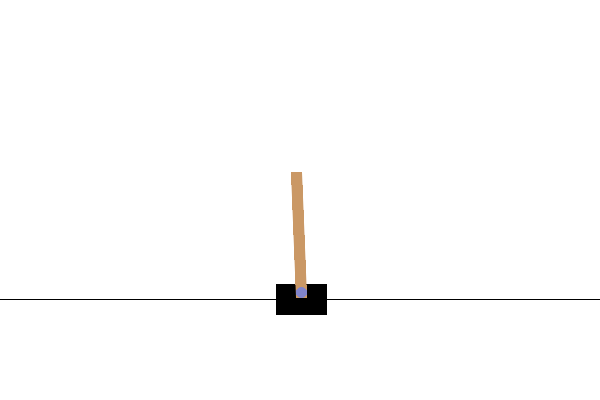


High ε=0.85 | frames=15 | return=14.0 | term=True | trunc=False

--- Animated GIF (high ε: lots of random exploration) ---


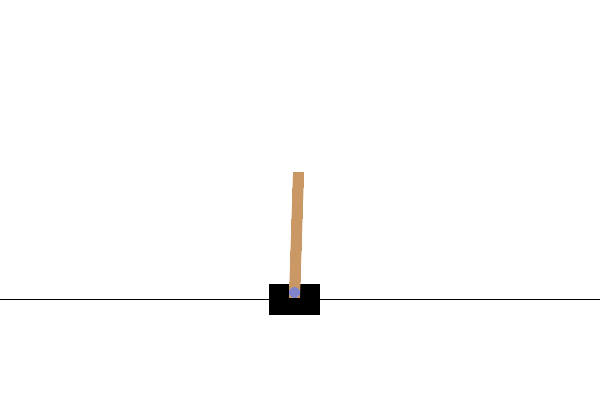


Teaching read: compare jerkiness vs steadiness. Return is not the main lesson here — ε controls how often we break the habit.


In [6]:
# Part 3c — connect epsilon-greedy to motion on CartPole (rgb_array frames).
# Run Part 2 first so `epsilon_greedy_action` is defined.

# ipywidgets / pillow are installed in the setup cell above; rerun that cell if imports fail.

import pathlib
import sys

# Find the shared Course 09 helper (course09_step_viz.py) from ANY folder, and on Google Colab.
# WHAT: look for the helper up the folder chain, then inside a "Course 09" folder on that chain,
#       and only then download it; finally put its folder on Python's import path.
# WHY:  searching only the PARENTS of the working directory breaks the moment you open this
#       notebook from the repository root - there the helper sits in a child folder, not a
#       parent - and on Colab there is no repository at all. This does not care where you
#       started the kernel from.
_HELPER_C9 = "course09_step_viz.py"
_chain_c9 = [pathlib.Path.cwd().resolve(), *pathlib.Path.cwd().resolve().parents]
_course09 = next((d for d in _chain_c9 if (d / _HELPER_C9).exists()), None)
if _course09 is None:                      # opened from the repo root, or from another course
    _course09 = next((d / "Course 09" for d in _chain_c9
                      if (d / "Course 09" / _HELPER_C9).exists()), None)
if _course09 is None:                      # Google Colab, or a stray copy of this notebook
    import urllib.request
    try:
        urllib.request.urlretrieve(
            "https://raw.githubusercontent.com/A-Alwabel/AI-Diploma-Program/main/"
            "Course%2009/" + _HELPER_C9, _HELPER_C9)
    except Exception as _e:
        raise FileNotFoundError(
            f"Could not find {_HELPER_C9} from this folder, and could not download it either. "
            "Open this notebook inside a clone of "
            "https://github.com/A-Alwabel/AI-Diploma-Program, or connect to the internet and "
            f"re-run this cell. (underlying error: {_e})") from None
    _course09 = pathlib.Path.cwd()

# Put that folder on Python's import path so the helper imports from any unit folder.
if str(_course09) not in sys.path:
    sys.path.insert(0, str(_course09))

import gymnasium as gym
import course09_step_viz as cs9viz

# Guard: this cell depends on a definition from an earlier part — fail fast with a clear message if it is missing.
if "epsilon_greedy_action" not in globals():
    raise RuntimeError("Run Part 2 first so `epsilon_greedy_action` exists, then rerun this cell.")

# Slight preference for action 1 (push right) at every step — a simple "habit" for exploitation to follow.
_q_cartpole_habit = np.array([-0.15, 0.15], dtype=float)
_n_actions_cartpole = 2


# Build an ε-greedy policy around the fixed 'habit' Q-values: exploit with prob. 1-ε, explore with prob. ε.
def _make_eps_policy(epsilon: float):
    def policy(obs, step):
        action, _mode = epsilon_greedy_action(_q_cartpole_habit, float(epsilon), _n_actions_cartpole)
        return int(action)

    return policy


# Record one CartPole episode at a given ε so low-ε and high-ε behaviour can be compared side by side.
def _rollout_cartpole_gif(epsilon: float, seed: int, *, max_steps: int = 140):
    env = gym.make("CartPole-v1", render_mode="rgb_array")
    pol = _make_eps_policy(epsilon)
    frames, total_r, term, trunc = cs9viz.collect_rollout_frames(
        env, pol, max_steps=max_steps, seed=seed
    )
    env.close()
    return frames, total_r, term, trunc


# Two contrasting settings: mostly-exploit (low ε) vs mostly-explore (high ε).
low_eps = 0.08
high_eps = 0.85

frames_low, ret_low, term_low, trunc_low = _rollout_cartpole_gif(low_eps, seed=0)
print(
    f"Low ε={low_eps:.2f}  | frames={len(frames_low)} | return={ret_low:.1f} | term={term_low} | trunc={trunc_low}"
)
print("\n--- Animated GIF (low ε: mostly exploitation of the habit) ---")
cs9viz.display_gif(frames_low, duration_ms=95)
cs9viz.display_step_slider(frames_low, title="CartPole — low ε timestep")

frames_high, ret_high, term_high, trunc_high = _rollout_cartpole_gif(high_eps, seed=3)
print(
    f"\nHigh ε={high_eps:.2f} | frames={len(frames_high)} | return={ret_high:.1f} | term={term_high} | trunc={trunc_high}"
)
print("\n--- Animated GIF (high ε: lots of random exploration) ---")
cs9viz.display_gif(frames_high, duration_ms=95)
cs9viz.display_step_slider(frames_high, title="CartPole — high ε timestep")

print(
    "\nTeaching read: compare jerkiness vs steadiness. Return is not the main lesson here — ε controls how often we break the habit."
)


## Part 3d (optional): Same ε idea on a grid (FrozenLake)

### Lesson Brief

CartPole (Part 3c) shows **continuous motion**. FrozenLake shows **discrete grid moves** with the same ε-greedy rule.

**Heads-up (goal tile `G`):** the fixed “habit” Q-bias here is chosen so ε changes what you see in **a few timesteps**. It is **not** tuned to reliably walk to the gift. Episodes may end early (hole, or max steps) **without** reaching `G` — that still demonstrates ε-greedy; it does **not** mean the method is “wrong” on this map.

We use `is_slippery=False` so the story stays readable for beginners. The Q-vector is again a **small fixed bias** (not a learned policy): it slightly prefers moving **down** at every state so exploitation is not “always pick action 0”.

### Step Guide

**What this cell does:** **Part 3d** — two short rollouts (low vs high ε) with GIF + slider, same helper as Part 2.

**How to read it (weak Python OK):** Watch how often the agent “wanders” off the bias direction when ε is high.

**What to expect in the output:** Two GIFs + two sliders.

**If you feel lost:** Re-run **Part 2**, then this cell (you do **not** need Part 3c first — the code cell imports the same helpers).

### Closing Takeaway (Parts 3c–3d)

ε is not only a bar chart: it changes **how often a policy breaks its current habit**. Same mechanism on a physics task (CartPole) and a grid task (FrozenLake).


FrozenLake low ε=0.10 | frames=26 | return=0.0 | term=True | trunc=False

--- GIF (low ε) ---


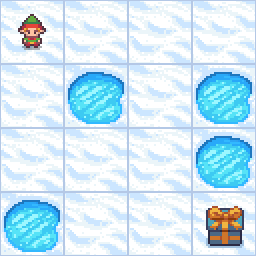


FrozenLake high ε=0.80 | frames=15 | return=0.0 | term=True | trunc=False

--- GIF (high ε) ---


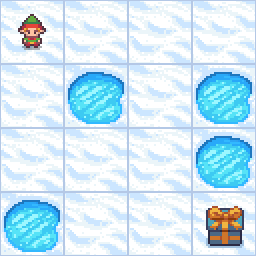

In [7]:
# Part 3d — FrozenLake rollouts (same epsilon_greedy_action as Part 2).

if "epsilon_greedy_action" not in globals():
    raise RuntimeError("Run Part 2 first so `epsilon_greedy_action` exists, then rerun this cell.")

# Same helper import path as Part 3c (keeps Part 3d runnable without running 3c first).
import pathlib
import sys

if "cs9viz" not in globals():
    # Find the shared Course 09 helper (course09_step_viz.py) from ANY folder, and on Google Colab.
    # WHAT: look for the helper up the folder chain, then inside a "Course 09" folder on that chain,
    #       and only then download it; finally put its folder on Python's import path.
    # WHY:  searching only the PARENTS of the working directory breaks the moment you open this
    #       notebook from the repository root - there the helper sits in a child folder, not a
    #       parent - and on Colab there is no repository at all. This does not care where you
    #       started the kernel from.
    _HELPER_C9 = "course09_step_viz.py"
    _chain_c9 = [pathlib.Path.cwd().resolve(), *pathlib.Path.cwd().resolve().parents]
    _course09 = next((d for d in _chain_c9 if (d / _HELPER_C9).exists()), None)
    if _course09 is None:                      # opened from the repo root, or from another course
        _course09 = next((d / "Course 09" for d in _chain_c9
                          if (d / "Course 09" / _HELPER_C9).exists()), None)
    if _course09 is None:                      # Google Colab, or a stray copy of this notebook
        import urllib.request
        try:
            urllib.request.urlretrieve(
                "https://raw.githubusercontent.com/A-Alwabel/AI-Diploma-Program/main/"
                "Course%2009/" + _HELPER_C9, _HELPER_C9)
        except Exception as _e:
            raise FileNotFoundError(
                f"Could not find {_HELPER_C9} from this folder, and could not download it either. "
                "Open this notebook inside a clone of "
                "https://github.com/A-Alwabel/AI-Diploma-Program, or connect to the internet and "
                f"re-run this cell. (underlying error: {_e})") from None
        _course09 = pathlib.Path.cwd()

    # Put that folder on Python's import path so the helper imports from any unit folder.
    if str(_course09) not in sys.path:
        sys.path.insert(0, str(_course09))

    import course09_step_viz as cs9viz  # noqa: E402

if "gym" not in globals():
    import gymnasium as gym  # noqa: E402

# Gymnasium FrozenLake-v1 actions: 0=left, 1=down, 2=right, 3=up
_q_lake_habit = np.array([0.02, 0.08, 0.02, 0.02], dtype=float)
_n_actions_lake = 4


# Same recipe as CartPole: follow the down-preferring habit with prob. 1-ε, act randomly with prob. ε.
def _make_lake_policy(epsilon: float):
    def policy(obs, step):
        action, _mode = epsilon_greedy_action(_q_lake_habit, float(epsilon), _n_actions_lake)
        return int(action)

    return policy


# Record one FrozenLake episode at the given ε (deterministic ice: is_slippery=False).
def _rollout_lake_gif(epsilon: float, seed: int, *, max_steps: int = 60):
    env = gym.make("FrozenLake-v1", is_slippery=False, render_mode="rgb_array")
    pol = _make_lake_policy(epsilon)
    frames, total_r, term, trunc = cs9viz.collect_rollout_frames(
        env, pol, max_steps=max_steps, seed=seed
    )
    env.close()
    return frames, total_r, term, trunc


# Contrast a mostly-exploiting walk with a mostly-random one on the same map.
low_eps_lake = 0.10
high_eps_lake = 0.80

fl_low, r_low, t_low, tr_low = _rollout_lake_gif(low_eps_lake, seed=11)
print(
    f"FrozenLake low ε={low_eps_lake:.2f} | frames={len(fl_low)} | return={r_low:.1f} | term={t_low} | trunc={tr_low}"
)
print("\n--- GIF (low ε) ---")
cs9viz.display_gif(fl_low, duration_ms=280)
cs9viz.display_step_slider(fl_low, title="FrozenLake — low ε timestep")

fl_high, r_high, t_high, tr_high = _rollout_lake_gif(high_eps_lake, seed=22)
print(
    f"\nFrozenLake high ε={high_eps_lake:.2f} | frames={len(fl_high)} | return={r_high:.1f} | term={t_high} | trunc={tr_high}"
)
print("\n--- GIF (high ε) ---")
cs9viz.display_gif(fl_high, duration_ms=280)
cs9viz.display_step_slider(fl_high, title="FrozenLake — high ε timestep")


## Part 4: Epsilon Decay Strategy

### What is epsilon decay?

With plain epsilon-greedy, **ε stays fixed**: the agent always explores with the same probability. In real training that is often wasteful:

- **Early**: Q-values are unreliable, so you want **more random tries** (high ε) to discover what works.
- **Later**: estimates stabilize, so you want **more greedy choices** (low ε) to squeeze reward from what you learned.

**Epsilon decay** means: **lower ε as training progresses** (a *schedule*), instead of one constant ε forever.

### Formula used in this notebook (exponential decay)

After episode index `t` (0-based in the code loop), we use:

\[
\varepsilon_t = \max(\varepsilon_{\min},\; \varepsilon_0 \cdot \rho^{\,t})
\]

- \(\varepsilon_0\): **initial** exploration rate (often `1.0` = “try everything”).
- \(\varepsilon_{\min}\): **floor** — we never go below this (keeps a little exploration).
- \(\rho\) (`decay_rate`): multiplier per episode. If `0 < ρ < 1`, each episode multiplies the *starting* exponential piece by \(\rho\) again; the curve is **exponential** (fast drop at first if ρ is small; **gentle** if ρ is close to `1`, e.g. `0.995`).

**Reading `decay_rate`:** values **closer to 1** → ε shrinks **slowly** (long exploration). Values **smaller** → ε drops **faster** (quickly more greedy). Always keep ρ in a sensible range for your episode count so ε does not vanish instantly unless you intend that.

**Other schedules (not coded here):** linear decay (ε drops by a fixed amount per episode), inverse decay, piecewise schedules, etc. The *idea* is the same: **high explore early, low explore late**.


### Step Guide

**What this cell does:** **Part 4** — simulates the **epsilon decay schedule** on its own: 500 episodes of the rule `eps_t = max(eps_min, eps_0 * rho^t)`. No rewards are involved yet — this cell is only about how exploration shrinks.

**How to read it (weak Python OK):** Track how ε falls from 1.0 toward the red floor line. The bandit rewards arrive in the worked example below this section.

**What to expect in the output:** One decay-curve figure plus printed ε checkpoints (episodes 100, 250, 500).

**If you feel lost:** Only ask “did exploration shrink over time?” That is the lesson.



Part 4: Epsilon Decay Strategy


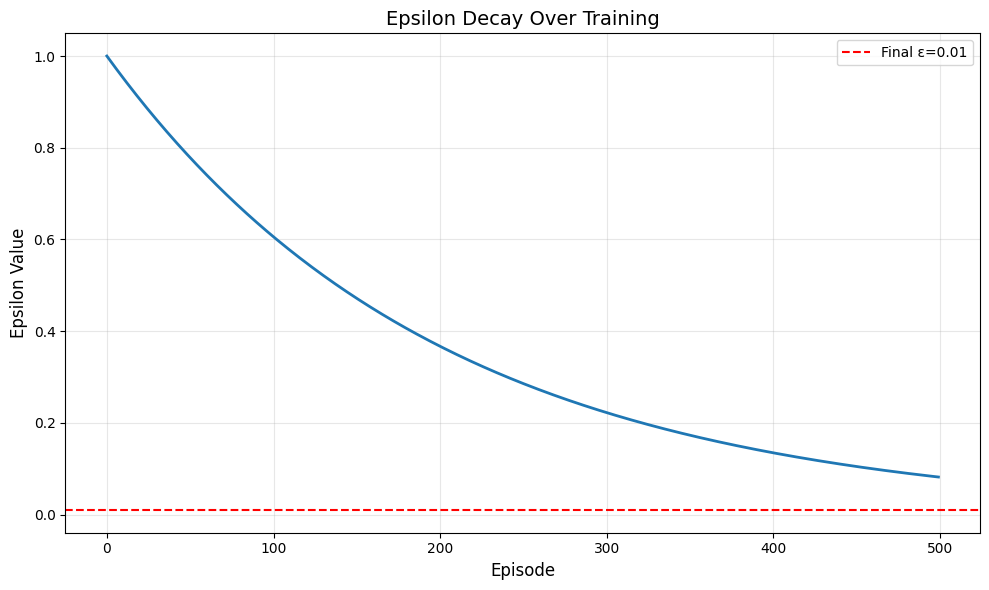


Epsilon Decay:
  Initial ε: 1.0
  Final ε: 0.01
  Decay rate: 0.995
  Episodes: 500
  ε at episode 100: 0.6058
  ε at episode 250: 0.2856
  ε at episode 500: 0.0820

✅ Epsilon decay strategy complete!


In [8]:
# Worked example: this cell runs the main scenario of the lesson step by step.
# Compare each printed result with the theory in the markdown so the execution tells a story.

# Show text or numbers in the cell output area under the code.
print("\n" + "=" * 60)
# Show text or numbers in the cell output area under the code.
print("Part 4: Epsilon Decay Strategy")
# Show text or numbers in the cell output area under the code.
print("=" * 60)

# Function `epsilon_decay` (what it does): Calculate epsilon with exponential decay. Args: initial_epsilon: Starting epsilon value final_epsilon: Minimum epsilon value de...
def epsilon_decay(initial_epsilon, final_epsilon, decay_rate, episode):
    """
    Calculate epsilon with exponential decay.
    
    Args:
        initial_epsilon: Starting epsilon value
        final_epsilon: Minimum epsilon value
        decay_rate: Decay rate (0.0 to 1.0)
        episode: Current episode number
    
    Returns:
        Decayed epsilon value
    """
    # Send a value back to whoever called this function.
    return max(final_epsilon, initial_epsilon * (decay_rate ** episode))

# Simulate epsilon decay over training
# Save a value in a name so the next lines can read it.
initial_epsilon = 1.0
# Another assignment—same idea: store a value for the lines below.
final_epsilon = 0.01
# Another assignment—same idea: store a value for the lines below.
decay_rate = 0.995
# Another assignment—same idea: store a value for the lines below.
n_episodes = 500

# Another assignment—same idea: store a value for the lines below.
epsilon_history = []
# Start a loop: repeat the indented block once per item in the sequence.
for episode in range(n_episodes):
    # Save a value in a name so the next lines can read it.
    epsilon = epsilon_decay(initial_epsilon, final_epsilon, decay_rate, episode)
    # Add one new item to the end of a list (the list grows in place).
    epsilon_history.append(epsilon)

# Visualize epsilon decay
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.figure(figsize=(10, 6))
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.plot(epsilon_history, linewidth=2)
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.xlabel('Episode', fontsize=12)
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.ylabel('Epsilon Value', fontsize=12)
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.title('Epsilon Decay Over Training', fontsize=14)
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.grid(True, alpha=0.3)
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.axhline(y=final_epsilon, color='r', linestyle='--', label=f'Final ε={final_epsilon}')
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.legend()
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.tight_layout()
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.show()

# Show text or numbers in the cell output area under the code.
print(f"\nEpsilon Decay:")
# Show text or numbers in the cell output area under the code.
print(f"  Initial ε: {initial_epsilon}")
# Show text or numbers in the cell output area under the code.
print(f"  Final ε: {final_epsilon}")
# Show text or numbers in the cell output area under the code.
print(f"  Decay rate: {decay_rate}")
# Show text or numbers in the cell output area under the code.
print(f"  Episodes: {n_episodes}")
# Show text or numbers in the cell output area under the code.
print(f"  ε at episode 100: {epsilon_history[100]:.4f}")
# Show text or numbers in the cell output area under the code.
print(f"  ε at episode 250: {epsilon_history[250]:.4f}")
# Show text or numbers in the cell output area under the code.
print(f"  ε at episode 500: {epsilon_history[499]:.4f}")

# Show text or numbers in the cell output area under the code.
print("\n✅ Epsilon decay strategy complete!")


## Worked Example: A Small Bandit Problem

A bandit problem is a clean way to understand exploration.

Imagine a website team testing several button designs. Each design has an unknown
click-through rate. The system must decide:

- should it keep showing the design that currently looks best?
- or should it still test other designs in case one is better?

That is exactly the exploration-exploitation dilemma.

### Step Guide

**What this cell does:** Loads standard imports for any follow-on plots or checks (NumPy/Matplotlib helpers).

**How to read it (weak Python OK):** Another “tool belt” cell—no new RL concept, just libraries.

**What to expect in the output:** Usually silent aside from import side effects.

**If you feel lost:** If everything above ran, you can skim this cell quickly.



Epsilon = 0.0
 Arm pulls: [500   0   0]
 Estimated values: [0.126 0.    0.   ]
 Average reward: 0.126

Epsilon = 0.1
 Arm pulls: [ 53 377  70]
 Estimated values: [0.17  0.329 0.257]
 Average reward: 0.302

Epsilon = 0.3
 Arm pulls: [ 46 402  52]
 Estimated values: [0.152 0.366 0.346]
 Average reward: 0.344


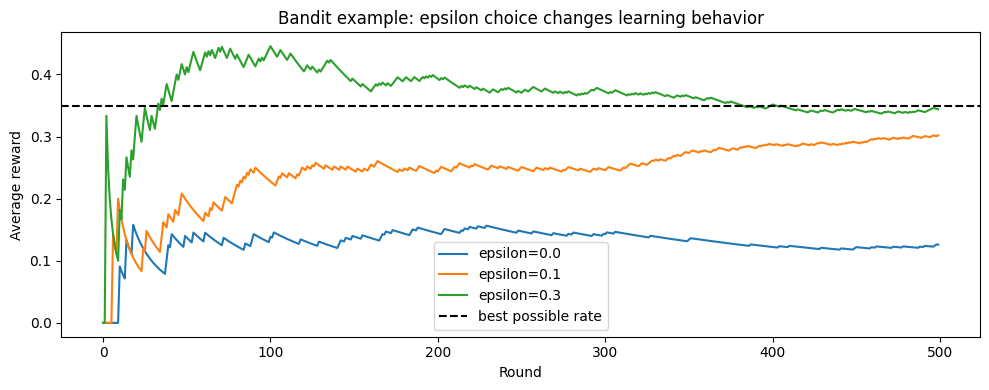


Teaching point:
- epsilon=0.0 can get stuck exploiting too early.
- a small epsilon often learns more safely.
- a very large epsilon explores a lot, but may exploit too slowly.


In [9]:
# Setup step: import the libraries that will carry the math, plotting, and learning logic.
# Reading the imports first helps students see which tools each later cell depends on.

# Load a library so you can use its ready-made functions and types below.
import numpy as np
# Load a library so you can use its ready-made functions and types below.
import matplotlib.pyplot as plt

# Use NumPy for fast numeric arrays and math on grids of numbers.
np.random.seed(42)
# Save a value in a name so the next lines can read it.
TRUE_RATES = np.array([0.15, 0.35, 0.25])
# Another assignment—same idea: store a value for the lines below.
N_ARMS = len(TRUE_RATES)
# Another assignment—same idea: store a value for the lines below.
N_ROUNDS = 500


# Function `pull` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: arm.
def pull(arm):
    # Send a value back to whoever called this function.
    return 1 if np.random.rand() < TRUE_RATES[arm] else 0


# Function `run_epsilon_greedy` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: epsilon.
def run_epsilon_greedy(epsilon):
    # Save a value in a name so the next lines can read it.
    counts = np.zeros(N_ARMS)
    # Another assignment—same idea: store a value for the lines below.
    value_estimates = np.zeros(N_ARMS)
    # Unpack the one-step model output from transition(state, action).
    rewards = []

    # Start a loop: repeat the indented block once per item in the sequence.
    for _ in range(N_ROUNDS):
        # Save a value in a name so the next lines can read it.
        action, _ = epsilon_greedy_action(value_estimates, epsilon, N_ARMS)
        # Unpack the one-step model output from transition(state, action).
        reward = pull(action)
        # Save a value in a name so the next lines can read it.
        counts[action] += 1
        # Another assignment—same idea: store a value for the lines below.
        value_estimates[action] += (reward - value_estimates[action]) / counts[action]
        # Add one new item to the end of a list (the list grows in place).
        rewards.append(reward)

    # Send a value back to whoever called this function.
    return counts, value_estimates, np.array(rewards)


# Save a value in a name so the next lines can read it.
results = {}
# Start a loop: repeat the indented block once per item in the sequence.
for epsilon in [0.0, 0.1, 0.3]:
    # Save a value in a name so the next lines can read it.
    counts, estimates, rewards = run_epsilon_greedy(epsilon)
    # Another assignment—same idea: store a value for the lines below.
    results[epsilon] = (counts, estimates, rewards)
    # Show text or numbers in the cell output area under the code.
    print(f"\nEpsilon = {epsilon}")
    # Show text or numbers in the cell output area under the code.
    print(" Arm pulls:", counts.astype(int))
    # Show text or numbers in the cell output area under the code.
    print(" Estimated values:", np.round(estimates, 3))
    # Show text or numbers in the cell output area under the code.
    print(" Average reward:", rewards.mean().round(3))

# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.figure(figsize=(10, 4))
# Start a loop: repeat the indented block once per item in the sequence.
for epsilon, (_, _, rewards) in results.items():
    # Save a value in a name so the next lines can read it.
    running_average = np.cumsum(rewards) / np.arange(1, len(rewards) + 1)
    # Use pyplot to create or tweak a figure (plot, labels, show, etc.).
    plt.plot(running_average, label=f"epsilon={epsilon}")
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.axhline(TRUE_RATES.max(), linestyle="--", color="black", label="best possible rate")
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.xlabel("Round")
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.ylabel("Average reward")
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.title("Bandit example: epsilon choice changes learning behavior")
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.legend()
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.tight_layout()
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.show()

# Show text or numbers in the cell output area under the code.
print("\nTeaching point:")
# Show text or numbers in the cell output area under the code.
print("- epsilon=0.0 can get stuck exploiting too early.")
# Show text or numbers in the cell output area under the code.
print("- a small epsilon often learns more safely.")
# Show text or numbers in the cell output area under the code.
print("- a very large epsilon explores a lot, but may exploit too slowly.")


## 💬 Discuss

The bandit results at the end of this notebook: ε=0.0 → **0.126**, ε=0.1 → **0.302**, ε=0.3 →
**0.344**. And the epsilon-decay schedule reached ε = **0.6058** at episode 100, **0.2856** at 250 and
**0.0820** at 500. Argue these out.

1. ε=0.3 beat ε=0.1 on this run (0.344 vs 0.302). Does that mean 0.3 is the better setting? What
   would you need to see before recommending it to someone paying for those pulls? (Unit 4 lesson 05
   answers this with 50 repeated runs — predict now what it will find.)
2. "Exploration" on the Yahoo front page means deliberately showing a reader an article you believe
   is worse for them. Is that acceptable? Write the sentence you would put in front of a product
   manager who asks "so we are showing people bad articles on purpose?" — then write the sentence
   the *sceptical* manager says back.
3. Now change the domain. Suppose the arms are treatment options for a patient, or price levels for
   a customer segment in the Saudi market. Which of those two would you refuse to run ε-greedy on,
   and what would you do instead? Your answer has to survive someone asking "but the maths is the
   same".


## Summary

You learned the first core exploration strategy used throughout RL:

- **epsilon-greedy** explores with probability `epsilon`
- otherwise it exploits the best current action estimate

### What to remember

- Exploration is necessary because the agent does not know the best action at the start.
- Exploitation is necessary because the agent must eventually use what it has learned.
- Epsilon decay is a practical way to move from more exploration to more exploitation over time.

### Important limitation

Epsilon-greedy is simple and useful, but it is not always the most efficient strategy.
More advanced exploration methods appear later in Unit 4.

### Next step

Move to `06_solving_rl_problems_states_actions_rewards.ipynb` or, if you already completed it,
continue to `07_mini_projects_cartpole_frozenlake_qlearning_dqn.ipynb`. 

In [10]:
# References (shown with Markdown inside a Python cell — avoids SyntaxError if a Markdown block is run as code.)
# Seminal papers first, then recent landmarks and surveys; linked entries were checked against their arXiv/publisher pages.
from IPython.display import Markdown, display

display(Markdown(r"""## 📚 References

1. Sutton, R. S. & Barto, A. G. (2018). *Reinforcement Learning: An Introduction* (2nd ed.). MIT Press. <http://incompleteideas.net/book/the-book-2nd.html> (free online) — see Ch. 2, Multi-armed Bandits — ε-greedy.
2. Auer, P., Cesa-Bianchi, N. & Fischer, P. (2002). *Finite-time Analysis of the Multiarmed Bandit Problem* (UCB1). Machine Learning, 47, 235-256. <https://link.springer.com/article/10.1023/A:1013689704352>
3. Russo, D., Van Roy, B., Kazerouni, A., Osband, I. & Wen, Z. (2018). *A Tutorial on Thompson Sampling*. Foundations and Trends in Machine Learning, 11(1), 1-96. <https://arxiv.org/abs/1707.02038>
4. Badia, A. P., Piot, B., Kapturowski, S. et al. (2020). *Agent57: Outperforming the Atari Human Benchmark*. ICML. <https://arxiv.org/abs/2003.13350>
5. Xu, W., Zhao, W., Wang, Z. et al. (2025). *EPO: Entropy-regularized Policy Optimization for LLM Agents Reinforcement Learning*. arXiv:2509.22576. <https://arxiv.org/abs/2509.22576> — the same exploration/exploitation trade-off in multi-turn, sparse-reward training, controlled by entropy rather than by ε.
6. Chen, P., Li, X., Li, Z., Yin, W., Chen, X. & Lin, T. (2025). *Exploration vs Exploitation: Rethinking RLVR through Clipping, Entropy, and Spurious Reward*. arXiv:2512.16912. <https://arxiv.org/abs/2512.16912> — why a score that went up is not, by itself, evidence that the exploration setting was the reason.
"""))

## 📚 References

1. Sutton, R. S. & Barto, A. G. (2018). *Reinforcement Learning: An Introduction* (2nd ed.). MIT Press. <http://incompleteideas.net/book/the-book-2nd.html> (free online) — see Ch. 2, Multi-armed Bandits — ε-greedy.
2. Auer, P., Cesa-Bianchi, N. & Fischer, P. (2002). *Finite-time Analysis of the Multiarmed Bandit Problem* (UCB1). Machine Learning, 47, 235-256. <https://link.springer.com/article/10.1023/A:1013689704352>
3. Russo, D., Van Roy, B., Kazerouni, A., Osband, I. & Wen, Z. (2018). *A Tutorial on Thompson Sampling*. Foundations and Trends in Machine Learning, 11(1), 1-96. <https://arxiv.org/abs/1707.02038>
4. Badia, A. P., Piot, B., Kapturowski, S. et al. (2020). *Agent57: Outperforming the Atari Human Benchmark*. ICML. <https://arxiv.org/abs/2003.13350>
5. Xu, W., Zhao, W., Wang, Z. et al. (2025). *EPO: Entropy-regularized Policy Optimization for LLM Agents Reinforcement Learning*. arXiv:2509.22576. <https://arxiv.org/abs/2509.22576> — the same exploration/exploitation trade-off in multi-turn, sparse-reward training, controlled by entropy rather than by ε.
6. Chen, P., Li, X., Li, Z., Yin, W., Chen, X. & Lin, T. (2025). *Exploration vs Exploitation: Rethinking RLVR through Clipping, Entropy, and Spurious Reward*. arXiv:2512.16912. <https://arxiv.org/abs/2512.16912> — why a score that went up is not, by itself, evidence that the exploration setting was the reason.


### Step Guide

**What this cell does:** Turns the bandit run's pull counts into one picture: how the 500 pulls were divided between the three arms, for each value of ε.

**How to read it (weak Python OK):** Each group of bars is one arm; the three bars inside a group are the three ε settings. Taller = pulled more often. The exact count is printed above every bar.

**What to expect in the output:** One grouped bar chart, plus a printed line per ε with the share of pulls that went to the best arm and the average reward that earned.

**If you feel lost:** Look only at the middle group (Arm 1, the best arm) and compare its three bars.

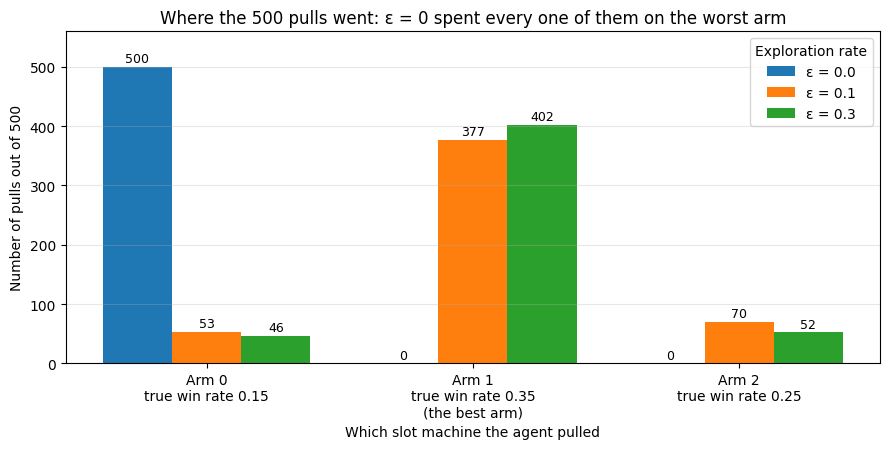

pulls per arm out of 500 rounds, and the reward that bought
  ε = 0.0: pulls = [500   0   0], share on the best arm =  0.0%, average reward = 0.126
  ε = 0.1: pulls = [ 53 377  70], share on the best arm = 75.4%, average reward = 0.302
  ε = 0.3: pulls = [ 46 402  52], share on the best arm = 80.4%, average reward = 0.344


In [11]:
# Where did the 500 pulls actually go? That is the question the whole lesson turns on,
# and the printed counts above answer it — but they are easier to compare as a picture.
# Arms are CATEGORIES, not a sequence: arm 2 does not follow arm 1 in any meaningful sense,
# so these are bars. Joining them with a line would invent an ordering that does not exist.

# Load a library so you can use its ready-made functions and types below.
import numpy as np
# Load a library so you can use its ready-made functions and types below.
import matplotlib.pyplot as plt

# `results` was rebuilt by the bandit cell above: epsilon -> (counts, estimates, rewards).
epsilons = sorted(results)
# The x positions: one slot per arm.
arm_positions = np.arange(N_ARMS)
# Three bars share each slot, one per epsilon setting.
bar_width = 0.26
# Which arm is genuinely the best? (We only know this because we wrote TRUE_RATES ourselves.)
best_arm = int(np.argmax(TRUE_RATES))

# One panel: pulls per arm, grouped by epsilon.
fig, ax = plt.subplots(figsize=(9, 4.6))
# Start a loop: repeat the indented block once per item in the sequence.
for slot, epsilon in enumerate(epsilons):
    # counts[arm] is how many of the N_ROUNDS pulls went to that arm.
    counts = results[epsilon][0]
    # Offset each epsilon's bars so the three sit side by side inside one arm's slot.
    offsets = arm_positions + (slot - 1) * bar_width
    # Draw this epsilon's three bars.
    bars = ax.bar(offsets, counts, bar_width, label=f"ε = {epsilon}")
    # Write the exact count above each bar: the picture and the number then agree by construction.
    for rect, count in zip(bars, counts):
        ax.text(rect.get_x() + rect.get_width() / 2, count + 8, f"{int(count)}",
                ha="center", fontsize=9)

# Tick labels say which arm AND how good it really is, so no axis needs the word "index".
ax.set_xticks(arm_positions)
ax.set_xticklabels([f"Arm {arm}\ntrue win rate {TRUE_RATES[arm]:.2f}"
                    + ("\n(the best arm)" if arm == best_arm else "")
                    for arm in range(N_ARMS)])
# Axis names in words.
ax.set_xlabel("Which slot machine the agent pulled")
ax.set_ylabel(f"Number of pulls out of {N_ROUNDS}")
# A title that states the claim the figure is making.
ax.set_title("Where the 500 pulls went: ε = 0 spent every one of them on the worst arm")
# Same plot panel as the line above—one more small plotting tweak.
ax.legend(title="Exploration rate")
# Same plot panel as the line above—one more small plotting tweak.
ax.grid(True, alpha=0.3, axis="y")
# Leave headroom for the number printed above the tallest bar.
ax.set_ylim(0, N_ROUNDS * 1.12)
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.tight_layout()
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.show()

# The same numbers as text, including what each setting earned per pull.
print(f"pulls per arm out of {N_ROUNDS} rounds, and the reward that bought")
# Start a loop: repeat the indented block once per item in the sequence.
for epsilon in epsilons:
    # Unpack this epsilon's run.
    counts, estimates, rewards = results[epsilon]
    # One line per epsilon setting.
    print(f"  ε = {epsilon}: pulls = {counts.astype(int)}, "
          f"share on the best arm = {counts[best_arm] / N_ROUNDS:5.1%}, "
          f"average reward = {rewards.mean():.3f}")


### 👁️ Read the figure

**What you are looking at.** The same 500-round bandit run from the cell above, seen from a different angle: not *how much reward* was earned, but *where the pulls went*. Three arms, three ε settings, one bar each. The tick labels carry each arm's true win rate — something the agent never knows.

**What to see.** The ε = 0 bar on Arm 0 is the whole story of this lesson: **500 pulls out of 500 on the worst arm** (true rate 0.15), and nothing at all on the other two. A greedy agent tried arm 0 first, got an early win, and never had any mechanism that would make it look elsewhere. Both exploring agents found Arm 1 instead and spent about three quarters of their budget there — 377 pulls at ε = 0.1 and 402 at ε = 0.3.

**The wrinkle worth noticing.** ε = 0.3 put *more* pulls on the best arm than ε = 0.1 did, even though it explores three times as often. That is not a contradiction: over only 500 rounds, ε = 0.1 spent its early rounds stuck on arm 0 before its rare random pulls uncovered arm 1, and it never made that time back. With a much longer run the ordering would flip, because ε = 0.3 keeps throwing away 30% of every future round.

**What it proves:** ε is not a tuning detail. At ε = 0 the agent's final estimate for arms 1 and 2 is literally 0.000 — it never collected a single sample of either — so it cannot know it chose badly. Exploration is what buys the information that makes exploitation worth anything.

## ⚠️ Where this breaks

**The assumption that has to hold:** the value of each action is fixed while you are learning it,
and exploring is cheap enough to be worth doing at random.

- **ε-greedy explores blindly.** When it explores, it picks *uniformly* — including the arm it has
  already sampled 400 times and knows is bad. Look at the ε=0.3 row above: 46 and 52 pulls were spent
  on the two losing arms. UCB and Thompson sampling (Unit 4) exist precisely to spend the exploration
  budget on the arms you are still *uncertain* about, not on all of them equally.
- **A fixed ε never stops paying.** With ε = 0.1 you are still throwing away one decision in ten
  after a million rounds. That is why decay exists — and the decay schedule (`0.995` here) is another
  number nobody measured; it is a guess that a rerun can overturn.
- **It assumes a stationary world.** If arm values drift — a news article going stale, seasonal
  demand, a competitor changing prices — a decayed ε leaves you unable to notice. In non-stationary
  settings you need exploration that comes *back*, or a sliding-window estimate.
- **Exploration can be unrecoverable.** Pulling a bad arm in a bandit costs one round. Taking an
  exploratory action on a physical robot, a live trading book or a patient can cost something you
  cannot undo. If a single bad action is unacceptable, ε-greedy is the wrong tool no matter how well
  it performs on this notebook's arms.
- **Cheaper alternative:** if your actions do *not* change the state of the world — which article,
  which banner, which of three prices — you have a bandit, not a full RL problem, and you should stay
  there. Bandits need far less data than RL and are far easier to defend. And if you only ever need
  one decision and can afford to wait, a fixed-split A/B test with a stopping rule is simpler than
  all of this, and a statistician can sign off on it.


## 🔭 State of the field (2026)

*Context, not examinable content — the official unit examines the technique above, exactly as it is taught. This box says where that technique sits on the 2026 map.*

ε-greedy is still the baseline every other exploration rule is measured against, and it is still the
first thing practitioners reach for. Where the frontier spends its exploration budget now is
language-model training, and there the knob is not ε but **entropy**: Xu *et al.* (2025) describe an
"exploration-exploitation cascade failure" in multi-turn, sparse-reward agent training — the policy
commits early to a confident, low-entropy strategy, and ordinary entropy regularisation applied later
"becomes counterproductive, promoting chaotic exploration that destabilizes training" — and control it
with a smoothed, phase-weighted entropy term instead. The first half of that failure is precisely your
ε = 0.0 run: the agent pulled arm 0 all 500 times for an average of 0.126, not because it was unlucky
but because it was right about the only arm it had ever seen. The second 2025–2026 lesson is harder to
hear: Chen *et al.* (2025) point out that *spurious rewards* (which discourage exploitation) and
*entropy minimisation* (which discourages exploration) have **both** been reported to raise reasoning
scores — so a number that went up is not by itself evidence that your exploration setting was the reason
it went up. Learn ε first because it is the smallest honest version of this knob: one visible number,
cheap enough to sweep fifty times, which is exactly what Unit 4 lesson 05 will ask you to do.

**Read:** Xu *et al.* (2025), <https://arxiv.org/abs/2509.22576> · Chen *et al.* (2025),
<https://arxiv.org/abs/2512.16912> (references 5-6 above).


## Closing Takeaway

**Teaching takeaway:** Epsilon-greedy balances trying what looks best now with occasionally exploring alternatives that may become better later.

**If students remember one idea:** Exploration is not randomness for its own sake. It is a strategy for avoiding premature confidence.

**Quick check before moving on:**
- Can you explain what happens when epsilon is too high or too low?
- Can you tell when an action was chosen for exploration versus exploitation?

**Link the visuals (Parts 3c–3d):** With **low ε**, motion tends to follow the fixed “habit” most of the time (steadier paths). With **high ε**, you should see more interrupted / jittery moves from random exploration. Scrub the sliders: pause on a step and ask whether the action still matches the bias direction, or looks like a random branch.

**Bridge to the next step:** Next, you will step back and learn how to formulate RL problems before choosing the right algorithm.

**For weaker coders:** If you can explain ε as “how often I try something random on purpose,” you already grasp epsilon-greedy; everything else is practice.
